In [ ]:
#importing the library
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/Social_Network_Ads_4552.csv')

#dataset inspection
print(dataset.head())
print(dataset.isnull().sum())
print(dataset.columns)
print(dataset.shape)

#Convert Male and Female into 0 and 1
dataset['Gender'] = dataset["Gender"].replace({"Male":0,"Female":1})

#choose independent and dependent variable
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:,-1].values


# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')
(400, 5)


/tmp/ipykernel_1489/4258458679.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Gender'] = dataset["Gender"].replace({"Male":0,"Female":1})


In [ ]:
# Training the Logistic Regression model on the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting a new result
print(classifier.predict(sc.transform([[1,32,150000]])))

# Predicting the Test set results
y_pred = classifier.predict(X_test)



[1]


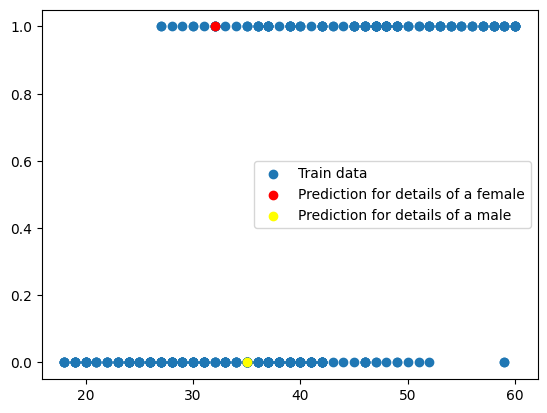

In [ ]:
#plot your graph

import matplotlib.pyplot as plt
plt.scatter(dataset['Age'],dataset['Purchased'])
plt.scatter(32,classifier.predict(sc.transform([[1,32,150000]])), color = 'red')
plt.scatter(35,classifier.predict(sc.transform([[0,35,20000]])),color = "yellow")
plt.legend(['Train data','Prediction for details of a female','Prediction for details of a male'])
plt.show()


